This comprehensive report includes:

1. **Strong Scaling Analysis**: How performance improves with more cores for fixed data size
2. **Weak Scaling Analysis**: How performance holds with increasing data and cores
3. **Pipeline Stage Analysis**: Which stages are bottlenecks
4. **Resource Utilization**: CPU, memory, GC, shuffle analysis
5. **Summary Statistics**: Key metrics overview
6. **Recommendations**: Best configurations based on your data

In [19]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [20]:
# Load your CSV
df = pd.read_csv("outputs/scaling_results_20260306_1455.csv")

In [21]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22 entries, 0 to 21
Data columns (total 31 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Type            22 non-null     object 
 1   Execs           22 non-null     int64  
 2   Cores           22 non-null     int64  
 3   TotalCores      22 non-null     int64  
 4   MemGB           22 non-null     int64  
 5   Data            22 non-null     object 
 6   AppID           22 non-null     object 
 7   S1              22 non-null     float64
 8   S2              22 non-null     float64
 9   S3              22 non-null     float64
 10  S4              22 non-null     float64
 11  S5a             22 non-null     float64
 12  S5b             22 non-null     float64
 13  S6a             22 non-null     float64
 14  S6b             22 non-null     float64
 15  TotalTime       22 non-null     float64
 16  AppTimeMs       22 non-null     int64  
 17  ExecRunTimeMs   22 non-null     int64

In [22]:
df.head()

,Type,Execs,Cores,TotalCores,MemGB,Data,AppID,S1,S2,S3,...,ShuffleReadMs,ShuffleWriteMs,CommMs,CommRatio,ComputeMs,ComputeRatio,MemSpillMB,DiskSpillMB,PeakHeapMB,Run
0,Strong,2,4,8,8,small_2,application_1772492797887_0418,83.275715,18.037021,173.352211,...,24759,7967.340609,32726.340609,0.004907,6.508767e+06,0.975946,4096.0,1246.727818,2841.702385,1
1,Strong,2,4,8,8,small_2,application_1772492797887_0421,79.278612,18.818305,176.119899,...,24782,7119.985944,31901.985944,0.004794,6.493664e+06,0.975822,4096.0,1246.727818,2943.304123,2
2,Strong,2,4,8,8,small_2,application_1772492797887_0427,83.471000,17.936557,174.220089,...,31584,7079.945382,38663.945382,0.005664,6.659900e+06,0.975636,4096.0,1246.727818,2962.337837,3
3,Strong,4,4,16,8,small_2,application_1772492797887_0439,86.075155,17.719478,120.552096,...,110457,7676.113402,118133.113402,0.015984,7.141788e+06,0.966324,4096.0,1246.727818,1693.298676,1
4,Strong,4,4,16,8,small_2,application_1772492797887_0442,93.292741,25.678370,166.839224,...,122300,7694.417596,129994.417596,0.017363,7.216917e+06,0.963920,4096.0,1246.727818,1967.279388,2


In [23]:
# Configuration columns (same across runs)
config_cols = ["Type","Execs","Cores","TotalCores","MemGB","Data"]

# Average the runs
df_avg = df.groupby(config_cols).mean(numeric_only=True).reset_index()

df_avg.head()

,Type,Execs,Cores,TotalCores,MemGB,Data,S1,S2,S3,S4,...,ShuffleReadMs,ShuffleWriteMs,CommMs,CommRatio,ComputeMs,ComputeRatio,MemSpillMB,DiskSpillMB,PeakHeapMB,Run
0,Strong,2,4,8,8,small_2,82.008442,18.263961,174.564066,160.223475,...,27041.666667,7389.090645,34430.757312,0.005122,6.554110e+06,0.975802,4096.0,1246.727818,2915.781448,2.0
1,Strong,4,4,16,8,small_2,100.487490,21.673324,134.264293,109.022374,...,117273.000000,8143.817331,125416.817331,0.016492,7.341082e+06,0.965018,4096.0,1246.727818,2124.631365,2.0
2,Strong,8,4,32,8,small_2,99.711121,19.834622,86.058458,65.357022,...,326100.333333,10171.691719,336272.025053,0.042597,7.391237e+06,0.936687,4096.0,1246.727818,2832.463120,2.0
3,Strong,16,4,64,8,small_2,87.794765,18.096319,48.847528,35.148977,...,667783.333333,15247.334496,683030.667829,0.071666,8.622964e+06,0.904318,4096.0,1246.727818,2738.779905,2.0
4,Strong,32,4,128,8,small_2,92.825879,18.080312,46.635156,32.703335,...,879364.000000,17265.530155,896629.530155,0.085644,9.319993e+06,0.888713,4096.0,1246.727818,2330.028493,2.0


In [36]:
strong = df_avg[df_avg["Type"] == "Strong"]
weak = df_avg[df_avg["Type"] == "Weak"]
memory = df_avg[df_avg["Type"] == "Memory"]

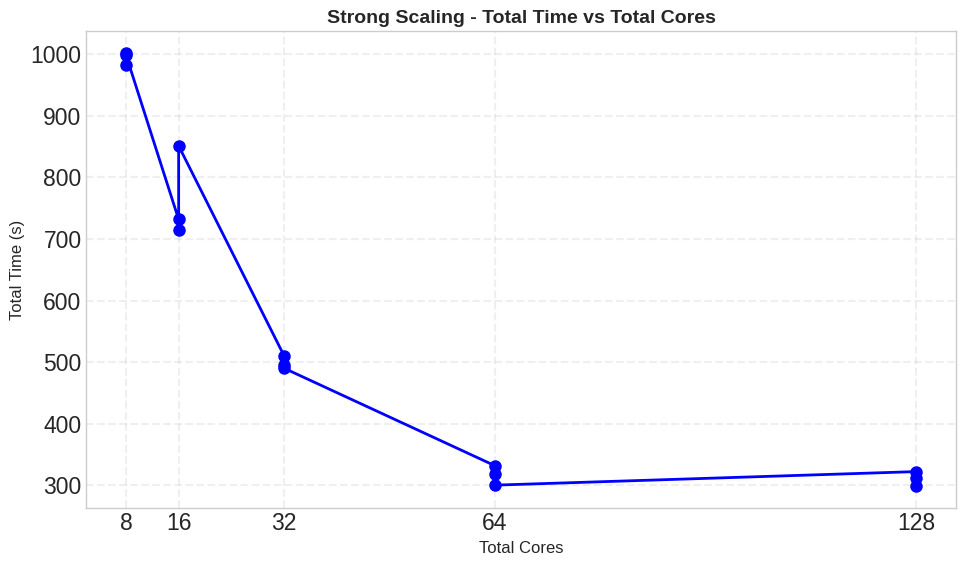

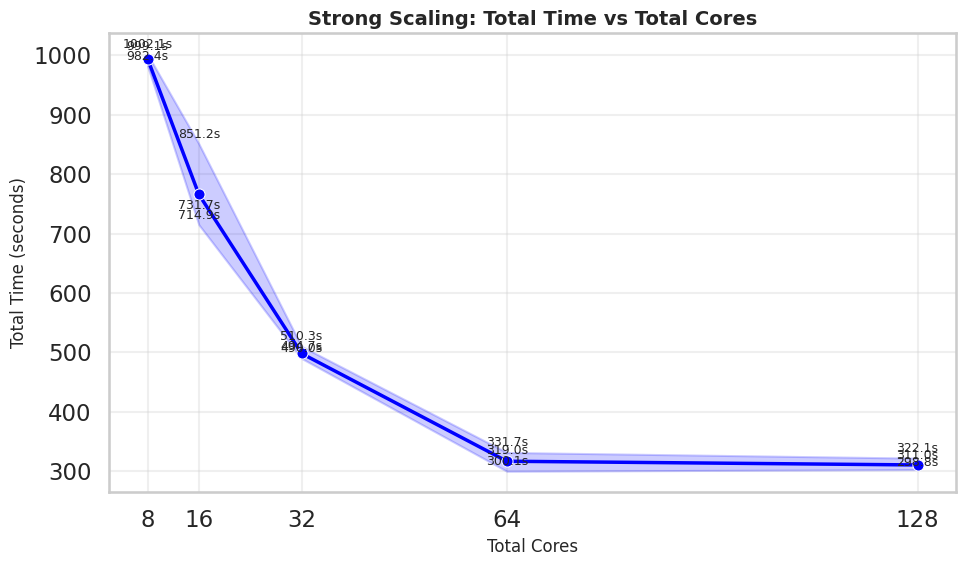

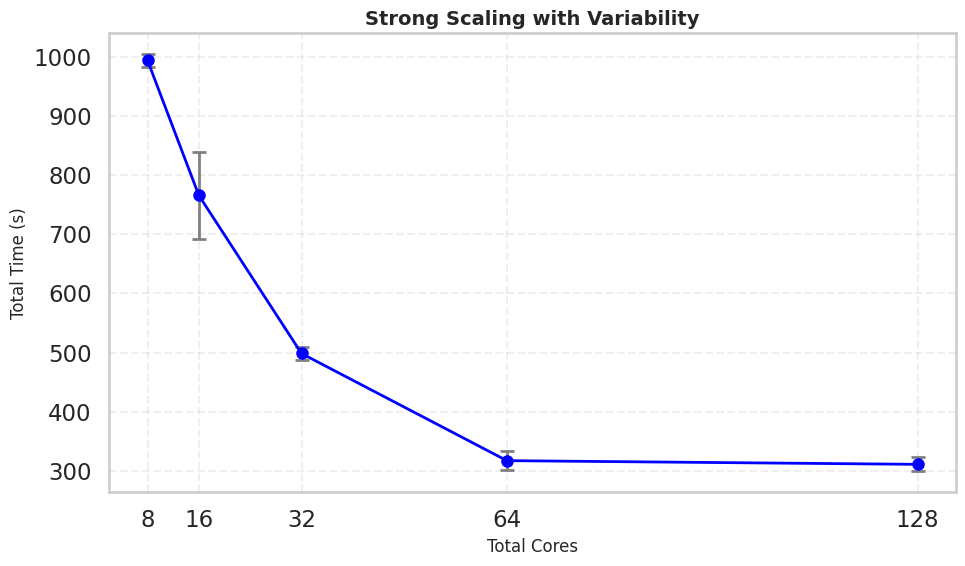

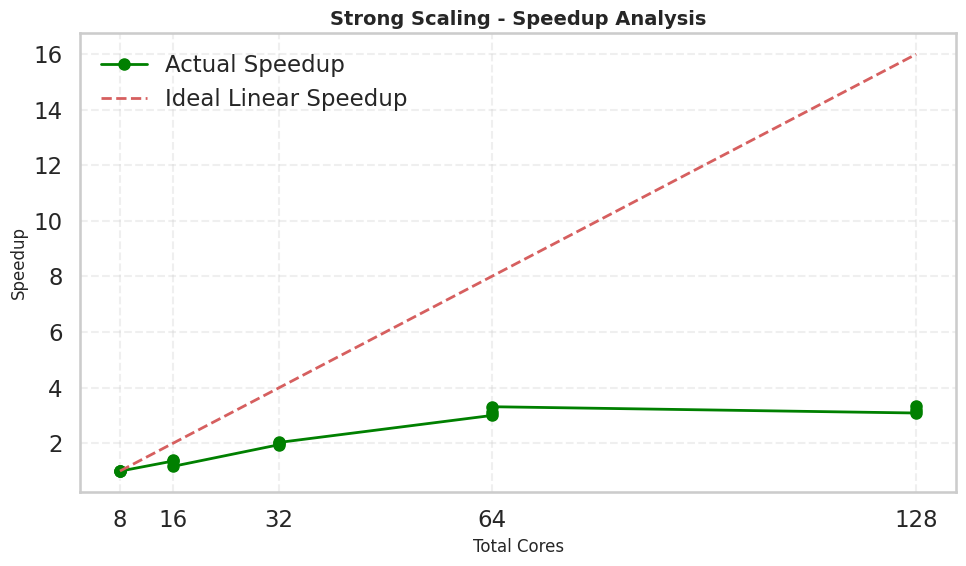

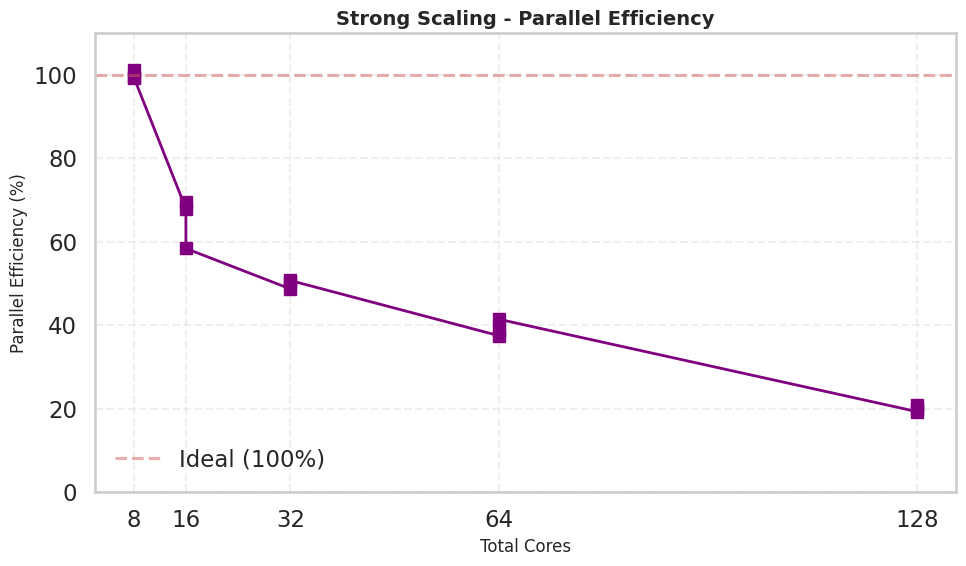

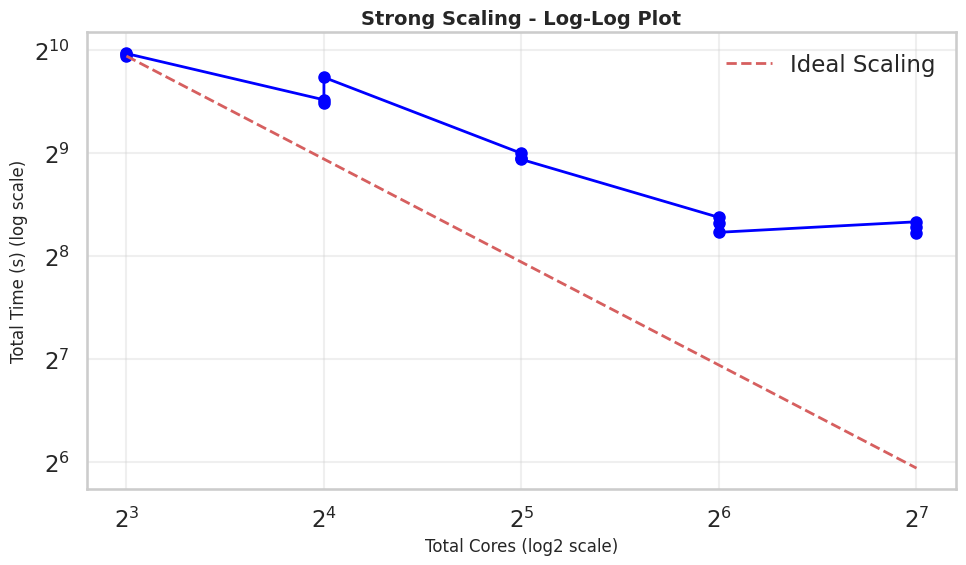

In [77]:
# First, filter the data for Strong scaling experiments
strong_df = df[df['Type'] == 'Strong'].copy()

# Sort by TotalCores for proper line plotting
strong_df = strong_df.sort_values('TotalCores')

# ============================================
# Option 1: Simple Matplotlib Version (Fixed)
# ============================================
plt.figure(figsize=(10, 6))
plt.plot(strong_df["TotalCores"], strong_df["TotalTime"], 
         marker='o', linewidth=2, markersize=8, color='blue')
plt.xlabel("Total Cores", fontsize=12)
plt.ylabel("Total Time (s)", fontsize=12)
plt.title("Strong Scaling - Total Time vs Total Cores", fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3, linestyle='--')
plt.xticks(strong_df["TotalCores"].unique())
plt.tight_layout()
plt.show()

# ============================================
# Option 2: Seaborn Version (Fixed)
# ============================================
import seaborn as sns
import matplotlib.pyplot as plt

# Set seaborn style
sns.set(style="whitegrid", palette="muted", context="talk")

# Total Time vs Total Cores
plt.figure(figsize=(10, 6))

# Use the filtered strong_df
sns.lineplot(data=strong_df, x='TotalCores', y='TotalTime', 
             marker='o', linewidth=2.5, markersize=8, color='blue')

plt.title("Strong Scaling: Total Time vs Total Cores", fontsize=14, fontweight='bold')
plt.xlabel("Total Cores", fontsize=12)
plt.ylabel("Total Time (seconds)", fontsize=12)
plt.xticks(strong_df['TotalCores'].unique())
plt.grid(True, alpha=0.3)

# Add value labels on points
for _, row in strong_df.iterrows():
    plt.text(row['TotalCores'], row['TotalTime'] + 5, 
             f"{row['TotalTime']:.1f}s", 
             ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

# ============================================
# Option 3: Multiple Runs with Error Bars
# ============================================
# If you have multiple runs per configuration
strong_stats = strong_df.groupby('TotalCores').agg({
    'TotalTime': ['mean', 'std', 'min', 'max']
}).reset_index()
strong_stats.columns = ['TotalCores', 'mean_time', 'std_time', 'min_time', 'max_time']

plt.figure(figsize=(10, 6))

# Plot mean with error bars
plt.errorbar(strong_stats['TotalCores'], strong_stats['mean_time'], 
             yerr=strong_stats['std_time'], 
             marker='o', capsize=5, capthick=2, 
             linewidth=2, markersize=8, color='blue', ecolor='gray')

plt.xlabel("Total Cores", fontsize=12)
plt.ylabel("Total Time (s)", fontsize=12)
plt.title("Strong Scaling with Variability", fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3, linestyle='--')
plt.xticks(strong_stats['TotalCores'].unique())
plt.tight_layout()
plt.show()

# ============================================
# Option 4: Speedup Plot
# ============================================
base_time = strong_df[strong_df['TotalCores'] == strong_df['TotalCores'].min()]['TotalTime'].mean()
strong_df['Speedup'] = base_time / strong_df['TotalTime']
strong_df['Ideal_Speedup'] = strong_df['TotalCores'] / strong_df['TotalCores'].min()

plt.figure(figsize=(10, 6))

plt.plot(strong_df["TotalCores"], strong_df["Speedup"], 
         'o-', linewidth=2, markersize=8, color='green', label='Actual Speedup')
plt.plot(strong_df["TotalCores"], strong_df["Ideal_Speedup"], 
         'r--', linewidth=2, label='Ideal Linear Speedup')

plt.xlabel("Total Cores", fontsize=12)
plt.ylabel("Speedup", fontsize=12)
plt.title("Strong Scaling - Speedup Analysis", fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3, linestyle='--')
plt.xticks(strong_df["TotalCores"].unique())
plt.legend()
plt.tight_layout()
plt.show()

# ============================================
# Option 5: Efficiency Plot
# ============================================
strong_df['Efficiency'] = (strong_df['Speedup'] / strong_df['Ideal_Speedup']) * 100

plt.figure(figsize=(10, 6))

plt.plot(strong_df["TotalCores"], strong_df["Efficiency"], 
         's-', linewidth=2, markersize=8, color='purple')
plt.axhline(y=100, color='r', linestyle='--', alpha=0.5, label='Ideal (100%)')

plt.xlabel("Total Cores", fontsize=12)
plt.ylabel("Parallel Efficiency (%)", fontsize=12)
plt.title("Strong Scaling - Parallel Efficiency", fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3, linestyle='--')
plt.xticks(strong_df["TotalCores"].unique())
plt.ylim(0, 110)
plt.legend()
plt.tight_layout()
plt.show()

# ============================================
# Option 6: Log-Log Plot (Better for scaling visualization)
# ============================================
plt.figure(figsize=(10, 6))

plt.loglog(strong_df["TotalCores"], strong_df["TotalTime"], 
           'o-', linewidth=2, markersize=8, color='blue', base=2)

# Add ideal scaling line (slope = -1 in log-log)
ideal_times = strong_df['TotalTime'].iloc[0] * (strong_df['TotalCores'].iloc[0] / strong_df['TotalCores'])
plt.loglog(strong_df["TotalCores"], ideal_times, 
           'r--', linewidth=2, label='Ideal Scaling', base=2)

plt.xlabel("Total Cores (log2 scale)", fontsize=12)
plt.ylabel("Total Time (s) (log scale)", fontsize=12)
plt.title("Strong Scaling - Log-Log Plot", fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3, which='both')
plt.legend()
plt.tight_layout()
plt.show()

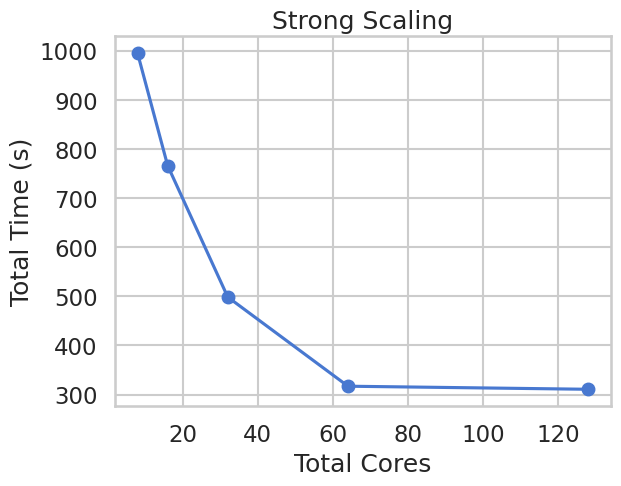

In [51]:
# 2. Strong Scaling Plot (Total Time vs Total Cores)

plt.figure()
plt.plot(strong["TotalCores"], strong["TotalTime"], marker='o')
plt.xlabel("Total Cores")
plt.ylabel("Total Time (s)")
plt.title("Strong Scaling")
plt.grid(True)
plt.show()

# # Set seaborn style
# sns.set(style="whitegrid", palette="muted", context="talk")

# #Total Time vs Total Cores
# plt.figure(figsize=(10,6))
# sns.lineplot(data=df, x='TotalCores', y='TotalTime', hue='Type', marker='o')
# plt.title("Total Time vs Total Cores")
# plt.xlabel("Total Cores")
# plt.ylabel("Total Time (s)")
# plt.xticks(df['TotalCores'].unique())
# plt.tight_layout()
# plt.show()

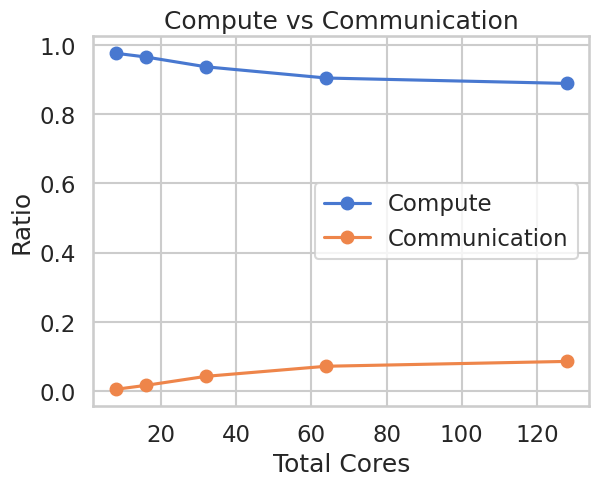

In [52]:
# 3. Compute vs Communication Breakdown

plt.figure()

plt.plot(strong["TotalCores"], strong["ComputeRatio"], marker='o', label="Compute")
plt.plot(strong["TotalCores"], strong["CommRatio"], marker='o', label="Communication")

plt.xlabel("Total Cores")
plt.ylabel("Ratio")
plt.title("Compute vs Communication")
plt.legend()
plt.grid(True)
plt.show()

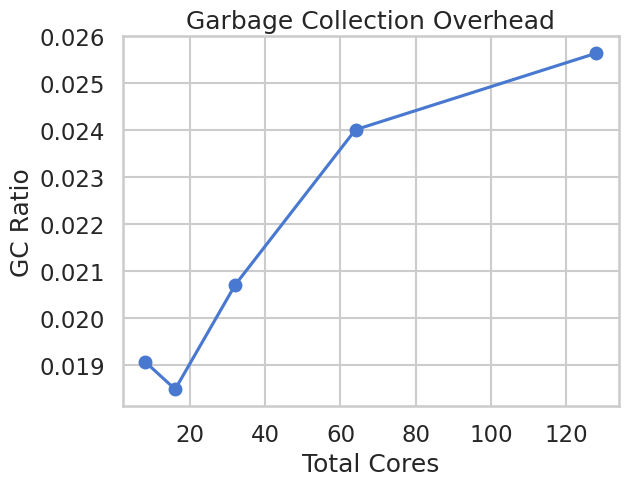

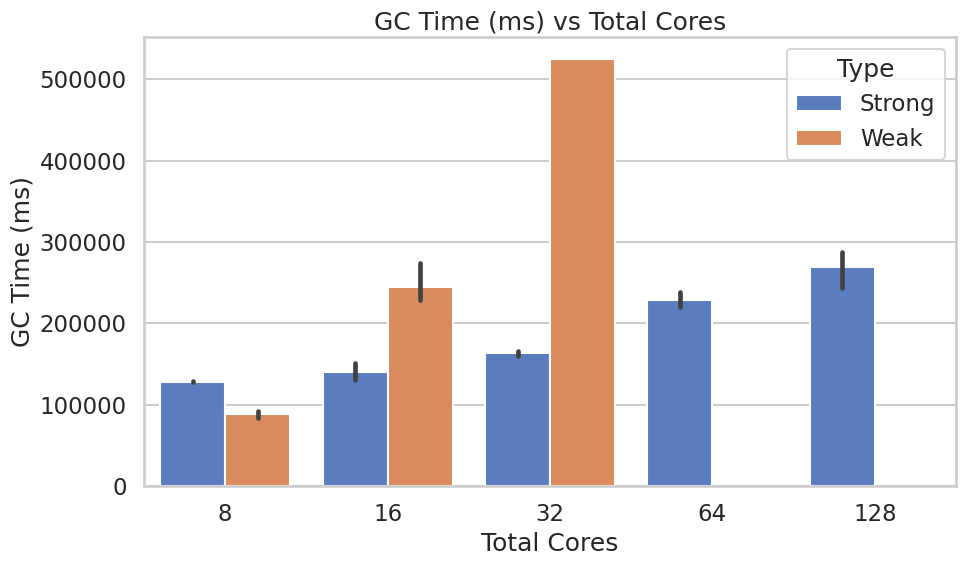

In [53]:
# 4. GC Overhead Plot

plt.figure()

plt.plot(strong["TotalCores"], strong["GCRatio"], marker='o')

plt.xlabel("Total Cores")
plt.ylabel("GC Ratio")
plt.title("Garbage Collection Overhead")
plt.grid(True)
plt.show()



# GC Time vs Total Cores
plt.figure(figsize=(10,6))
sns.barplot(data=df, x='TotalCores', y='GCms', hue='Type')
plt.title("GC Time (ms) vs Total Cores")
plt.xlabel("Total Cores")
plt.ylabel("GC Time (ms)")
plt.tight_layout()
plt.show()


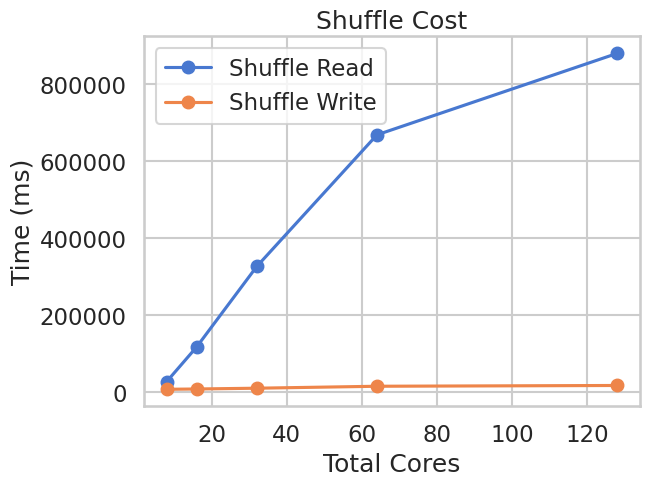

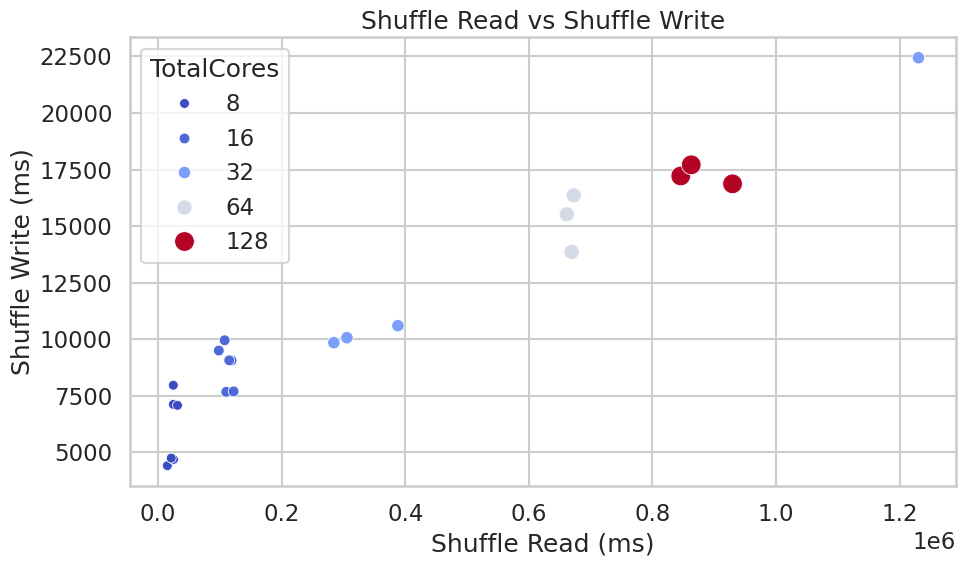

In [54]:
# 5. Shuffle Cost Plot

plt.figure()

plt.plot(strong["TotalCores"], strong["ShuffleReadMs"], marker='o', label="Shuffle Read")
plt.plot(strong["TotalCores"], strong["ShuffleWriteMs"], marker='o', label="Shuffle Write")

plt.xlabel("Total Cores")
plt.ylabel("Time (ms)")
plt.title("Shuffle Cost")
plt.legend()
plt.grid(True)
plt.show()


# Shuffle Read vs Shuffle Write
plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='ShuffleReadMs', y='ShuffleWriteMs', hue='TotalCores', size='TotalCores', palette="coolwarm", sizes=(50,200))
plt.title("Shuffle Read vs Shuffle Write")
plt.xlabel("Shuffle Read (ms)")
plt.ylabel("Shuffle Write (ms)")
plt.tight_layout()
plt.show()



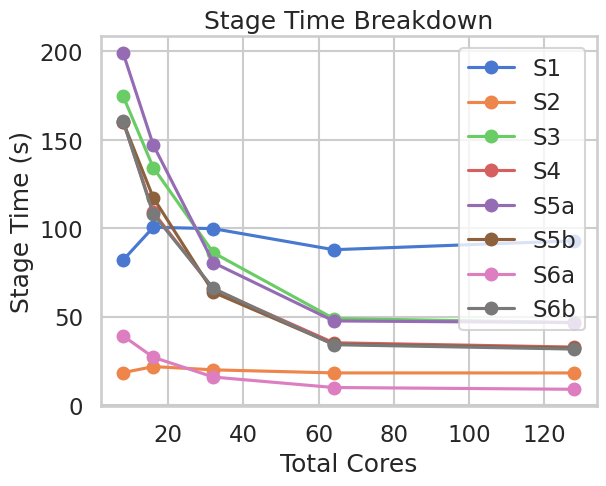

In [55]:
# 6. Stage Time Breakdown

stages = ["S1","S2","S3","S4","S5a","S5b","S6a","S6b"]

strong.set_index("TotalCores")[stages].plot(marker='o')

plt.xlabel("Total Cores")
plt.ylabel("Stage Time (s)")
plt.title("Stage Time Breakdown")
plt.grid(True)
plt.show()

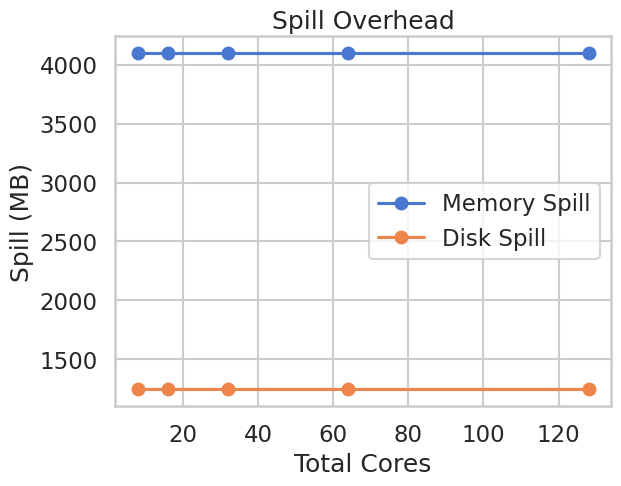

In [56]:
# 7. Memory Pressure Plot
plt.figure()

plt.plot(strong["TotalCores"], strong["MemSpillMB"], marker='o', label="Memory Spill")
plt.plot(strong["TotalCores"], strong["DiskSpillMB"], marker='o', label="Disk Spill")

plt.xlabel("Total Cores")
plt.ylabel("Spill (MB)")
plt.title("Spill Overhead")
plt.legend()
plt.grid(True)
plt.show()

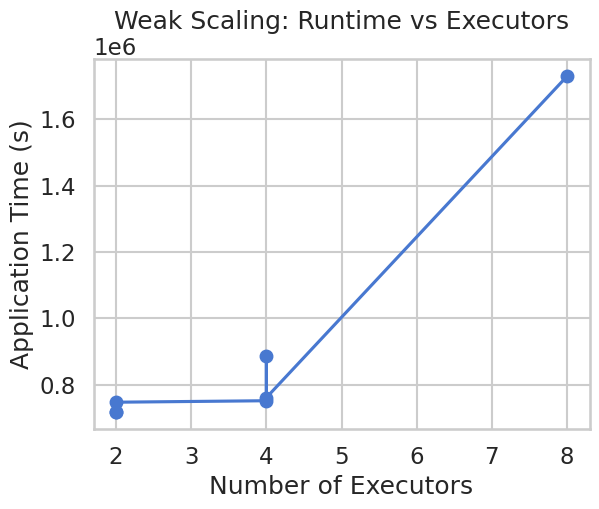

In [57]:
# ----------------------------
# 1 Runtime vs Executors
# ----------------------------
plt.figure()
plt.plot(weak["Execs"], weak["AppTimeMs"], marker='o')
plt.xlabel("Number of Executors")
plt.ylabel("Application Time (s)")
plt.title("Weak Scaling: Runtime vs Executors")
plt.grid(True)
plt.savefig("weak_runtime.png")

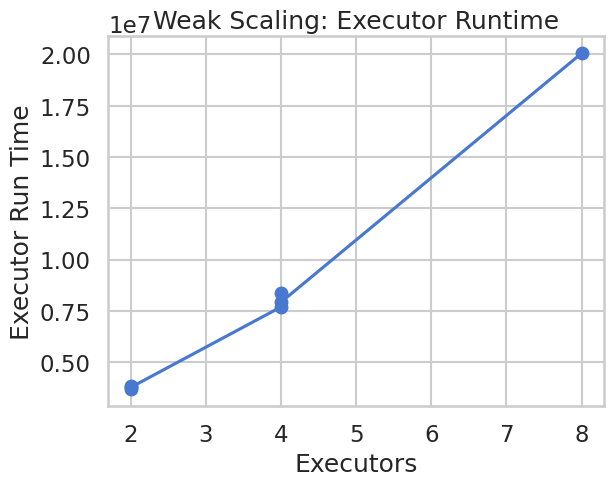

In [58]:
# ----------------------------
# 2 Executor Runtime
# ----------------------------
plt.figure()
plt.plot(weak["Execs"], weak["ExecRunTimeMs"], marker='o')
plt.xlabel("Executors")
plt.ylabel("Executor Run Time")
plt.title("Weak Scaling: Executor Runtime")
plt.grid(True)
plt.savefig("weak_executor_runtime.png")

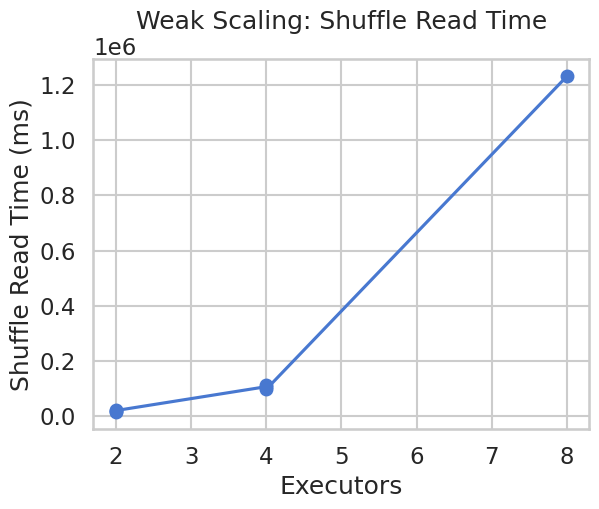

In [59]:
# ----------------------------
# 3 Shuffle Read Time
# ----------------------------
plt.figure()
plt.plot(weak["Execs"], weak["ShuffleReadMs"], marker='o')
plt.xlabel("Executors")
plt.ylabel("Shuffle Read Time (ms)")
plt.title("Weak Scaling: Shuffle Read Time")
plt.grid(True)
plt.savefig("weak_shuffle_time.png")

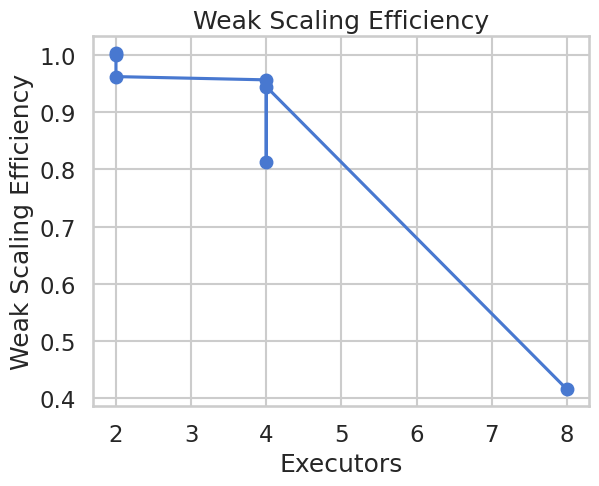

In [60]:
# ----------------------------
# 4 Weak Scaling Efficiency
# ----------------------------

t1 = weak.iloc[0]["AppTimeMs"]
weak["efficiency"] = t1 / weak["AppTimeMs"]

plt.figure()
plt.plot(weak["Execs"], weak["efficiency"], marker='o')
plt.xlabel("Executors")
plt.ylabel("Weak Scaling Efficiency")
plt.title("Weak Scaling Efficiency")
plt.grid(True)
plt.savefig("weak_efficiency.png")
plt.show()

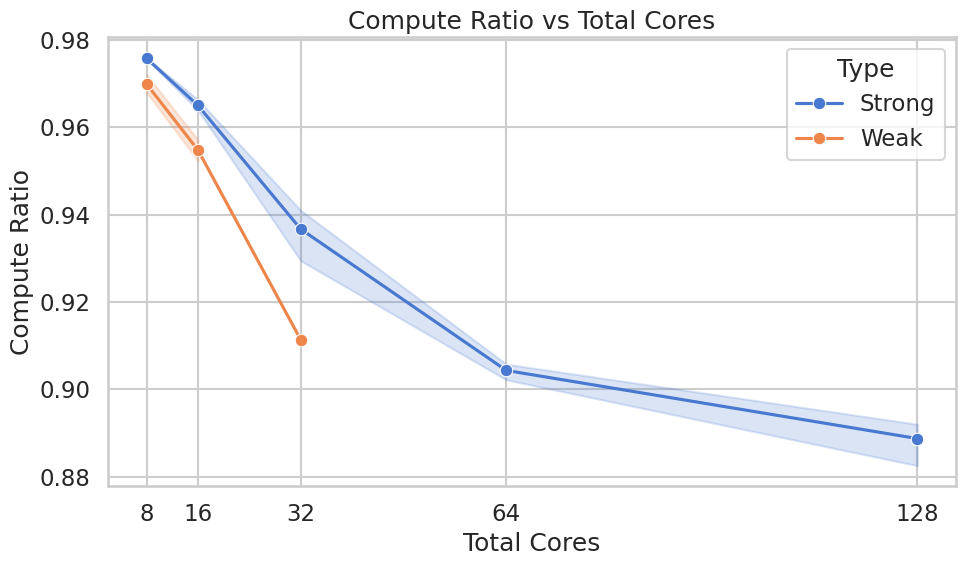

In [61]:
# Parallelism vs Compute Ratio
plt.figure(figsize=(10,6))
sns.lineplot(data=df, x='TotalCores', y='ComputeRatio', hue='Type', marker='o')
plt.title("Compute Ratio vs Total Cores")
plt.xlabel("Total Cores")
plt.ylabel("Compute Ratio")
plt.xticks(df['TotalCores'].unique())
plt.tight_layout()
plt.show()

In [62]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from matplotlib.ticker import ScalarFormatter
import warnings
warnings.filterwarnings('ignore')

In [63]:
# Set style for better plots
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")

In [64]:
df = pd.read_csv("outputs/scaling_results_20260306_1455.csv")

In [66]:
# Display basic info
print("Dataset Info:")
print(f"Total experiments: {len(df)}")
print(f"Columns: {df.columns.tolist()}")
print("\nFirst few rows:")
df.head()

Dataset Info:
Total experiments: 22
Columns: ['Type', 'Execs', 'Cores', 'TotalCores', 'MemGB', 'Data', 'AppID', 'S1', 'S2', 'S3', 'S4', 'S5a', 'S5b', 'S6a', 'S6b', 'TotalTime', 'AppTimeMs', 'ExecRunTimeMs', 'Parallelism', 'GCms', 'GCRatio', 'ShuffleReadMs', 'ShuffleWriteMs', 'CommMs', 'CommRatio', 'ComputeMs', 'ComputeRatio', 'MemSpillMB', 'DiskSpillMB', 'PeakHeapMB', 'Run']

First few rows:


,Type,Execs,Cores,TotalCores,MemGB,Data,AppID,S1,S2,S3,...,ShuffleReadMs,ShuffleWriteMs,CommMs,CommRatio,ComputeMs,ComputeRatio,MemSpillMB,DiskSpillMB,PeakHeapMB,Run
0,Strong,2,4,8,8,small_2,application_1772492797887_0418,83.275715,18.037021,173.352211,...,24759,7967.340609,32726.340609,0.004907,6.508767e+06,0.975946,4096.0,1246.727818,2841.702385,1
1,Strong,2,4,8,8,small_2,application_1772492797887_0421,79.278612,18.818305,176.119899,...,24782,7119.985944,31901.985944,0.004794,6.493664e+06,0.975822,4096.0,1246.727818,2943.304123,2
2,Strong,2,4,8,8,small_2,application_1772492797887_0427,83.471000,17.936557,174.220089,...,31584,7079.945382,38663.945382,0.005664,6.659900e+06,0.975636,4096.0,1246.727818,2962.337837,3
3,Strong,4,4,16,8,small_2,application_1772492797887_0439,86.075155,17.719478,120.552096,...,110457,7676.113402,118133.113402,0.015984,7.141788e+06,0.966324,4096.0,1246.727818,1693.298676,1
4,Strong,4,4,16,8,small_2,application_1772492797887_0442,93.292741,25.678370,166.839224,...,122300,7694.417596,129994.417596,0.017363,7.216917e+06,0.963920,4096.0,1246.727818,1967.279388,2


## 1. **Strong Scaling Analysis** (Fixed problem size, increasing resources)

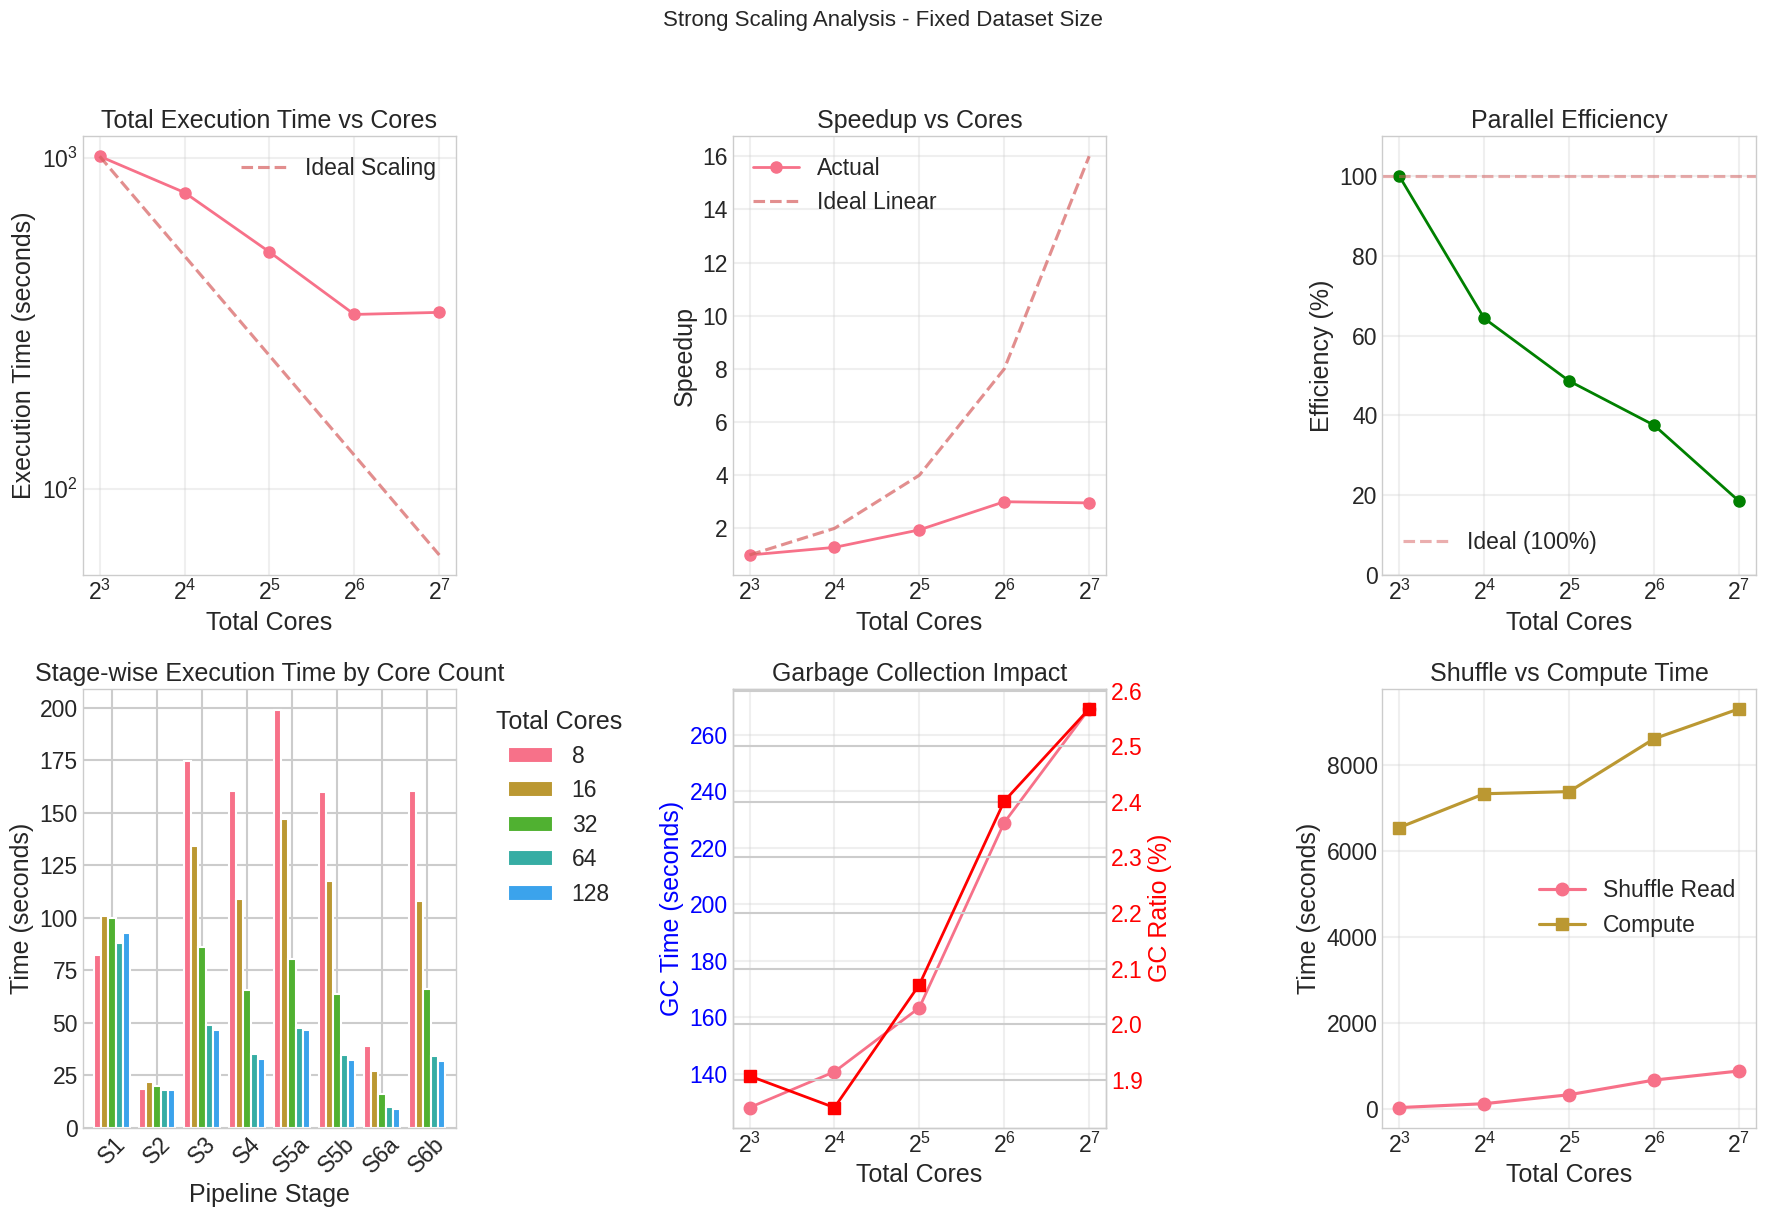

In [67]:

# Filter strong scaling data
strong_df = df[df['Type'] == 'Strong'].copy()
strong_df['TotalCores'] = strong_df['Execs'] * strong_df['Cores']

# Sort by cores
strong_df = strong_df.sort_values('TotalCores')

# Create figure with subplots
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle('Strong Scaling Analysis - Fixed Dataset Size', fontsize=16, y=1.02)

# 1. Execution Time vs Cores
ax1 = axes[0, 0]
cores = strong_df.groupby('TotalCores')['AppTimeMs'].mean().reset_index()
ax1.plot(cores['TotalCores'], cores['AppTimeMs']/1000, 'o-', linewidth=2, markersize=8)
ax1.set_xlabel('Total Cores')
ax1.set_ylabel('Execution Time (seconds)')
ax1.set_title('Total Execution Time vs Cores')
ax1.grid(True, alpha=0.3)
ax1.set_xscale('log', base=2)
ax1.set_yscale('log')

# Add ideal scaling line
ideal_time = cores['AppTimeMs'].iloc[0] / (cores['TotalCores'] / cores['TotalCores'].iloc[0])
ax1.plot(cores['TotalCores'], ideal_time/1000, 'r--', label='Ideal Scaling', alpha=0.7)
ax1.legend()

# 2. Speedup vs Cores
ax2 = axes[0, 1]
base_time = cores['AppTimeMs'].iloc[0]
speedup = base_time / cores['AppTimeMs']
ax2.plot(cores['TotalCores'], speedup, 'o-', linewidth=2, markersize=8, label='Actual')
ax2.plot(cores['TotalCores'], cores['TotalCores']/cores['TotalCores'].iloc[0], 
         'r--', label='Ideal Linear', alpha=0.7)
ax2.set_xlabel('Total Cores')
ax2.set_ylabel('Speedup')
ax2.set_title('Speedup vs Cores')
ax2.grid(True, alpha=0.3)
ax2.set_xscale('log', base=2)
ax2.legend()

# 3. Efficiency
ax3 = axes[0, 2]
efficiency = speedup / (cores['TotalCores'] / cores['TotalCores'].iloc[0]) * 100
ax3.plot(cores['TotalCores'], efficiency, 'o-', linewidth=2, markersize=8, color='green')
ax3.axhline(y=100, color='r', linestyle='--', alpha=0.5, label='Ideal (100%)')
ax3.set_xlabel('Total Cores')
ax3.set_ylabel('Efficiency (%)')
ax3.set_title('Parallel Efficiency')
ax3.grid(True, alpha=0.3)
ax3.set_xscale('log', base=2)
ax3.set_ylim(0, 110)
ax3.legend()

# 4. Stage-wise breakdown for different core counts
ax4 = axes[1, 0]
stage_cols = ['S1', 'S2', 'S3', 'S4', 'S5a', 'S5b', 'S6a', 'S6b']
stage_means = strong_df.groupby('TotalCores')[stage_cols].mean()

stage_means.T.plot(kind='bar', ax=ax4, width=0.8)
ax4.set_xlabel('Pipeline Stage')
ax4.set_ylabel('Time (seconds)')
ax4.set_title('Stage-wise Execution Time by Core Count')
ax4.legend(title='Total Cores', bbox_to_anchor=(1.05, 1))
ax4.tick_params(axis='x', rotation=45)

# 5. GC Time vs Cores
ax5 = axes[1, 1]
gc_data = strong_df.groupby('TotalCores')[['GCms', 'ExecRunTimeMs']].mean()
gc_ratio = gc_data['GCms'] / gc_data['ExecRunTimeMs'] * 100

ax5.plot(gc_data.index, gc_data['GCms']/1000, 'o-', linewidth=2, label='GC Time (s)')
ax5.set_xlabel('Total Cores')
ax5.set_ylabel('GC Time (seconds)', color='blue')
ax5.tick_params(axis='y', labelcolor='blue')
ax5.set_xscale('log', base=2)

ax5b = ax5.twinx()
ax5b.plot(gc_data.index, gc_ratio, 's-', color='red', linewidth=2, label='GC Ratio %')
ax5b.set_ylabel('GC Ratio (%)', color='red')
ax5b.tick_params(axis='y', labelcolor='red')
ax5.set_title('Garbage Collection Impact')
ax5.grid(True, alpha=0.3)

# 6. Shuffle vs Compute time
ax6 = axes[1, 2]
shuffle_compute = strong_df.groupby('TotalCores')[['ShuffleReadMs', 'ComputeMs']].mean() / 1000

ax6.plot(shuffle_compute.index, shuffle_compute['ShuffleReadMs'], 'o-', label='Shuffle Read')
ax6.plot(shuffle_compute.index, shuffle_compute['ComputeMs'], 's-', label='Compute')
ax6.set_xlabel('Total Cores')
ax6.set_ylabel('Time (seconds)')
ax6.set_title('Shuffle vs Compute Time')
ax6.set_xscale('log', base=2)
ax6.legend()
ax6.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('strong_scaling_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

## 2. **Weak Scaling Analysis** (Increasing problem size with resources)

In [69]:
# Filter weak scaling data
weak_df = df[df['Type'] == 'Weak'].copy()
weak_df['TotalCores'] = weak_df['Execs'] * weak_df['Cores']
weak_df = weak_df.sort_values('TotalCores')

# Group by dataset size and cores
weak_summary = weak_df.groupby(['Data', 'TotalCores']).agg({
    'AppTimeMs': 'mean',
    'ExecRunTimeMs': 'mean',
    'GCms': 'mean',
    'ShuffleReadMs': 'mean',
    'ComputeMs': 'mean'
}).reset_index()

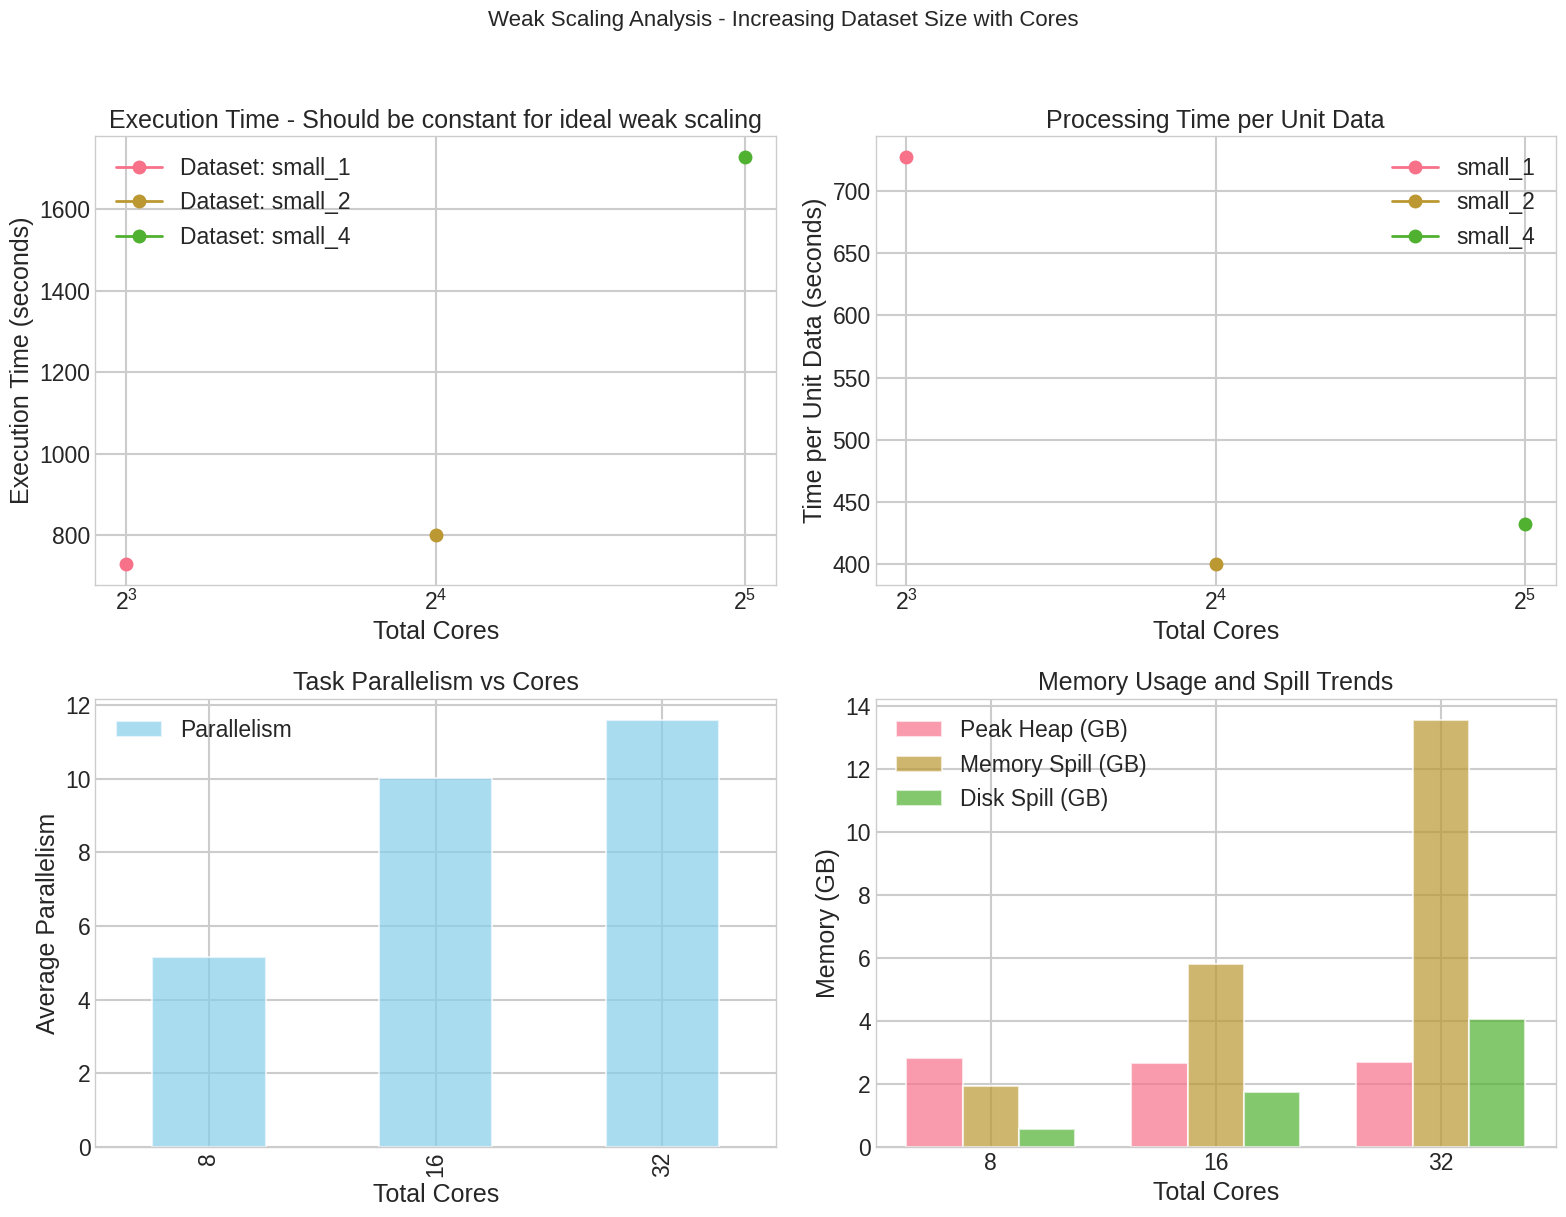

In [72]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Weak Scaling Analysis - Increasing Dataset Size with Cores', fontsize=16, y=1.02)

# 1. Execution Time vs Cores (should be constant for perfect weak scaling)
ax1 = axes[0, 0]
for dataset in weak_summary['Data'].unique():
    data_subset = weak_summary[weak_summary['Data'] == dataset]
    ax1.plot(data_subset['TotalCores'], data_subset['AppTimeMs']/1000, 
             'o-', linewidth=2, label=f'Dataset: {dataset}')

ax1.set_xlabel('Total Cores')
ax1.set_ylabel('Execution Time (seconds)')
ax1.set_title('Execution Time - Should be constant for ideal weak scaling')
ax1.set_xscale('log', base=2)
ax1.legend()
# ax1.grid(True, alpha=0.3)

# 2. Time per unit data
ax2 = axes[0, 1]
for dataset in weak_summary['Data'].unique():
    data_subset = weak_summary[weak_summary['Data'] == dataset]
    # Approximate dataset size from name (small_1, small_2, small_4)
    size_factor = int(dataset.split('_')[1]) if '_' in dataset else 1
    time_per_unit = data_subset['AppTimeMs'] / size_factor
    ax2.plot(data_subset['TotalCores'], time_per_unit/1000, 
             'o-', linewidth=2, label=f'{dataset}')

ax2.set_xlabel('Total Cores')
ax2.set_ylabel('Time per Unit Data (seconds)')
ax2.set_title('Processing Time per Unit Data')
ax2.set_xscale('log', base=2)
ax2.legend()
# ax2.grid(True, alpha=3)

# 3. Resource utilization
ax3 = axes[1, 0]
metrics = weak_df.groupby('TotalCores')[['Parallelism', 'GCRatio', 'CommRatio']].mean()
metrics['Parallelism'].plot(kind='bar', ax=ax3, color='skyblue', alpha=0.7)
ax3.set_xlabel('Total Cores')
ax3.set_ylabel('Average Parallelism')
ax3.set_title('Task Parallelism vs Cores')
ax3.legend(['Parallelism'])

# 4. Memory and spill trends
ax4 = axes[1, 1]
mem_data = weak_df.groupby('TotalCores')[['PeakHeapMB', 'MemSpillMB', 'DiskSpillMB']].mean()
x = range(len(mem_data.index))
width = 0.25

ax4.bar([i - width for i in x], mem_data['PeakHeapMB']/1024, width, label='Peak Heap (GB)', alpha=0.7)
ax4.bar(x, mem_data['MemSpillMB']/1024, width, label='Memory Spill (GB)', alpha=0.7)
ax4.bar([i + width for i in x], mem_data['DiskSpillMB']/1024, width, label='Disk Spill (GB)', alpha=0.7)

ax4.set_xlabel('Total Cores')
ax4.set_ylabel('Memory (GB)')
ax4.set_title('Memory Usage and Spill Trends')
ax4.set_xticks(x)
ax4.set_xticklabels(mem_data.index)
ax4.legend()

plt.tight_layout()
plt.savefig('weak_scaling_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

## 3. **Pipeline Stage Analysis**

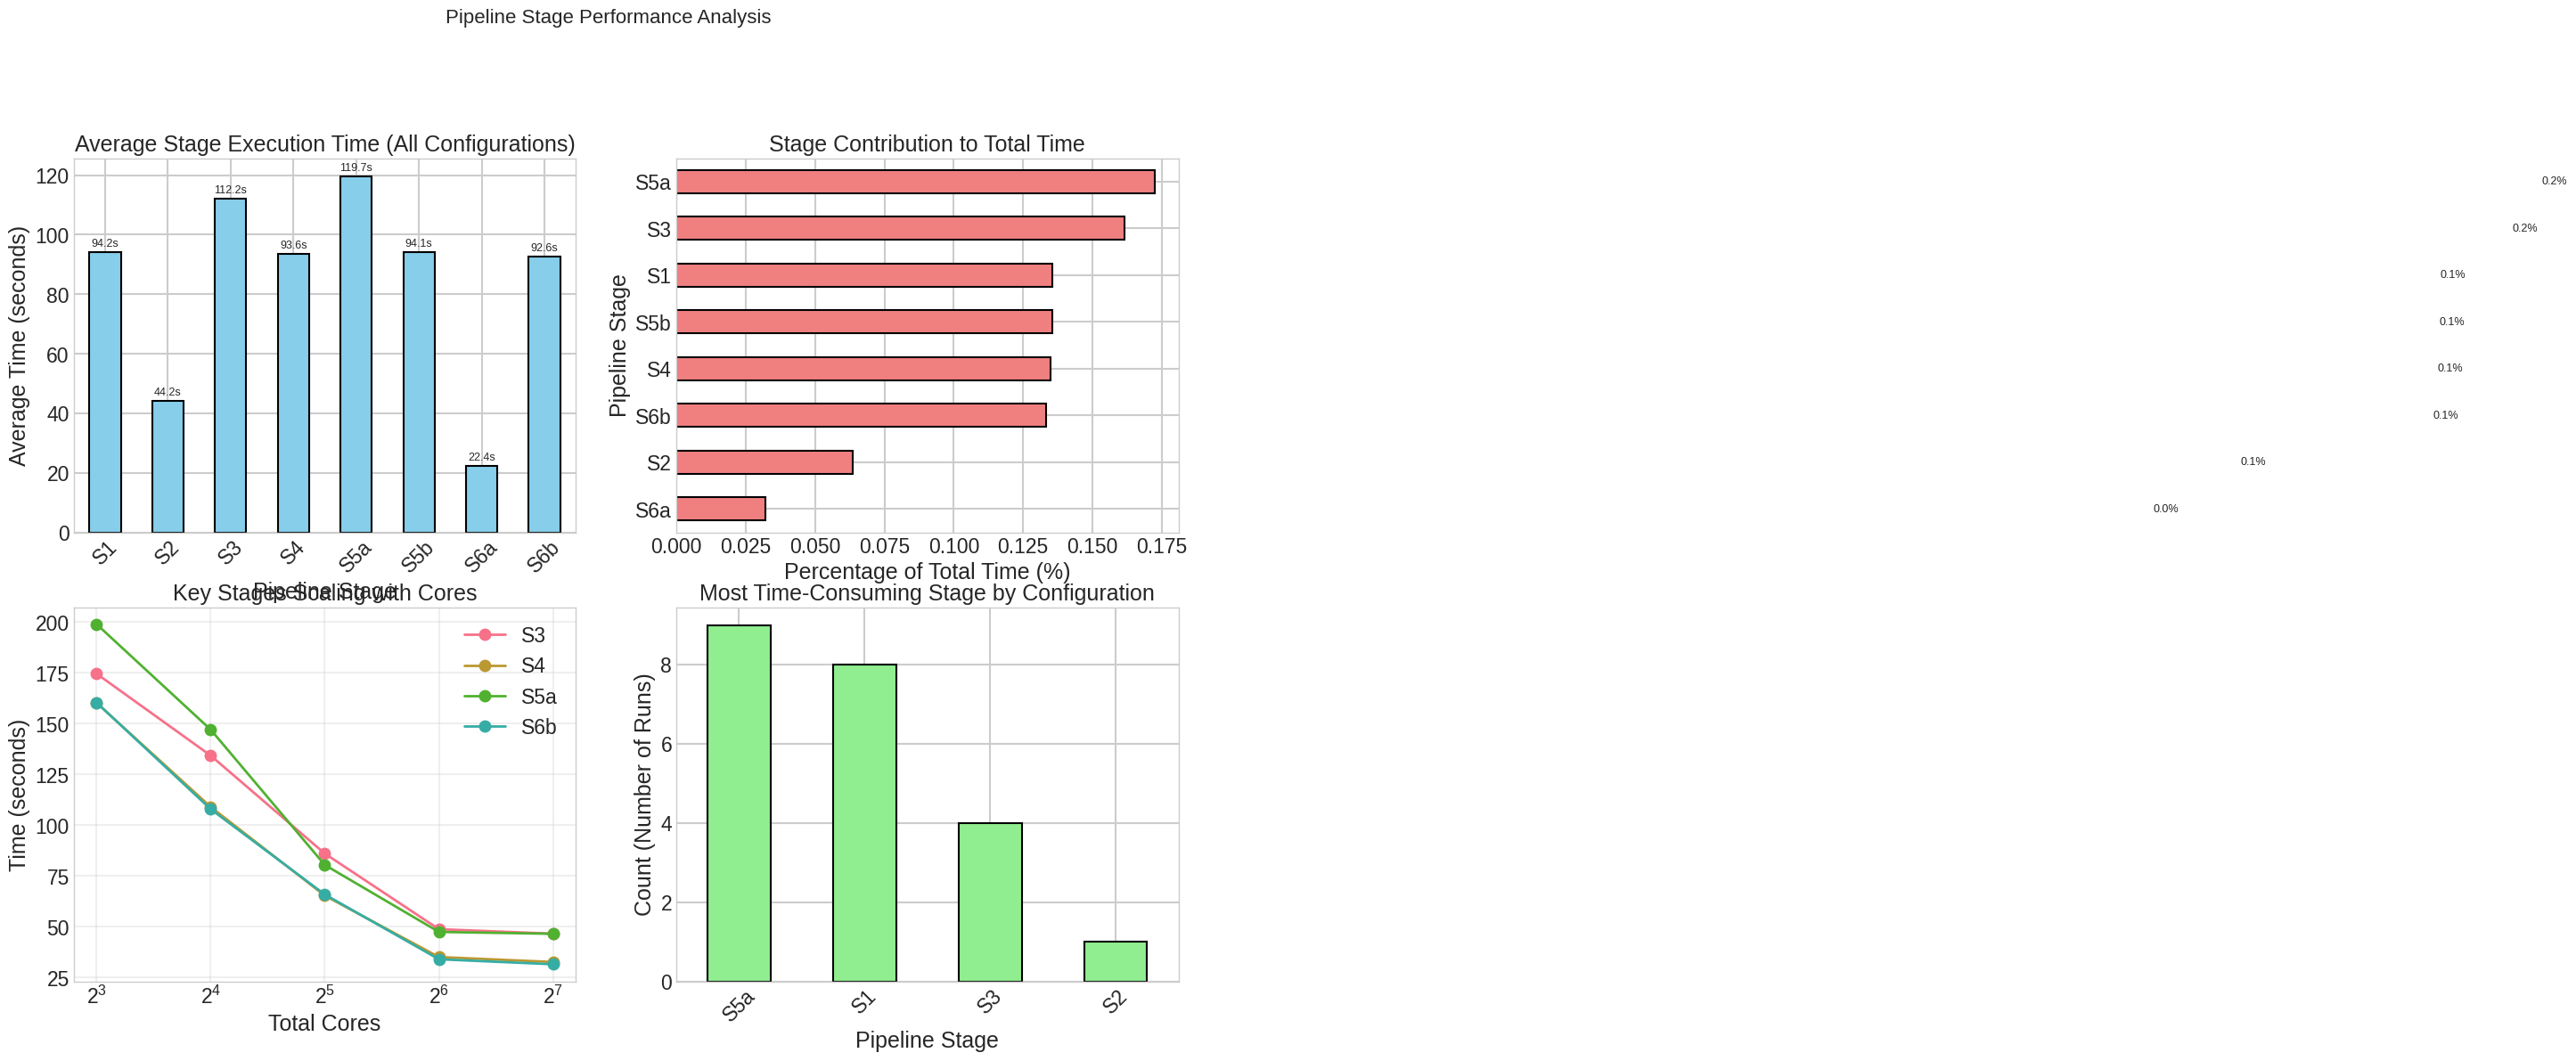

In [73]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Pipeline Stage Performance Analysis', fontsize=16, y=1.02)

# 1. Stage time distribution for different configurations
ax1 = axes[0, 0]
stage_cols = ['S1', 'S2', 'S3', 'S4', 'S5a', 'S5b', 'S6a', 'S6b']
stage_means_all = df[stage_cols].mean()

stage_means_all.plot(kind='bar', ax=ax1, color='skyblue', edgecolor='black')
ax1.set_xlabel('Pipeline Stage')
ax1.set_ylabel('Average Time (seconds)')
ax1.set_title('Average Stage Execution Time (All Configurations)')
ax1.tick_params(axis='x', rotation=45)

# Add value labels on bars
for i, v in enumerate(stage_means_all):
    ax1.text(i, v + 1, f'{v:.1f}s', ha='center', va='bottom', fontsize=9)

# 2. Stage time as percentage of total
ax2 = axes[0, 1]
stage_pct = (stage_means_all / df['AppTimeMs'].mean() * 1000).sort_values(ascending=True)

stage_pct.plot(kind='barh', ax=ax2, color='lightcoral', edgecolor='black')
ax2.set_xlabel('Percentage of Total Time (%)')
ax2.set_ylabel('Pipeline Stage')
ax2.set_title('Stage Contribution to Total Time')

# Add value labels
for i, v in enumerate(stage_pct):
    ax2.text(v + 0.5, i, f'{v:.1f}%', va='center', fontsize=9)

# 3. Stage scaling with cores (select a few key stages)
ax3 = axes[1, 0]
key_stages = ['S3', 'S4', 'S5a', 'S6b']
strong_core_groups = strong_df.groupby('TotalCores')[key_stages].mean()

for stage in key_stages:
    ax3.plot(strong_core_groups.index, strong_core_groups[stage], 
             'o-', linewidth=2, label=stage)

ax3.set_xlabel('Total Cores')
ax3.set_ylabel('Time (seconds)')
ax3.set_title('Key Stages Scaling with Cores')
ax3.set_xscale('log', base=2)
ax3.legend()
ax3.grid(True, alpha=0.3)

# 4. Most time-consuming stage per configuration
ax4 = axes[1, 1]
stage_max = df[stage_cols].idxmax(axis=1)
stage_max_counts = stage_max.value_counts()

stage_max_counts.plot(kind='bar', ax=ax4, color='lightgreen', edgecolor='black')
ax4.set_xlabel('Pipeline Stage')
ax4.set_ylabel('Count (Number of Runs)')
ax4.set_title('Most Time-Consuming Stage by Configuration')
ax4.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('pipeline_stage_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

## 4. **Resource Utilization Analysis**

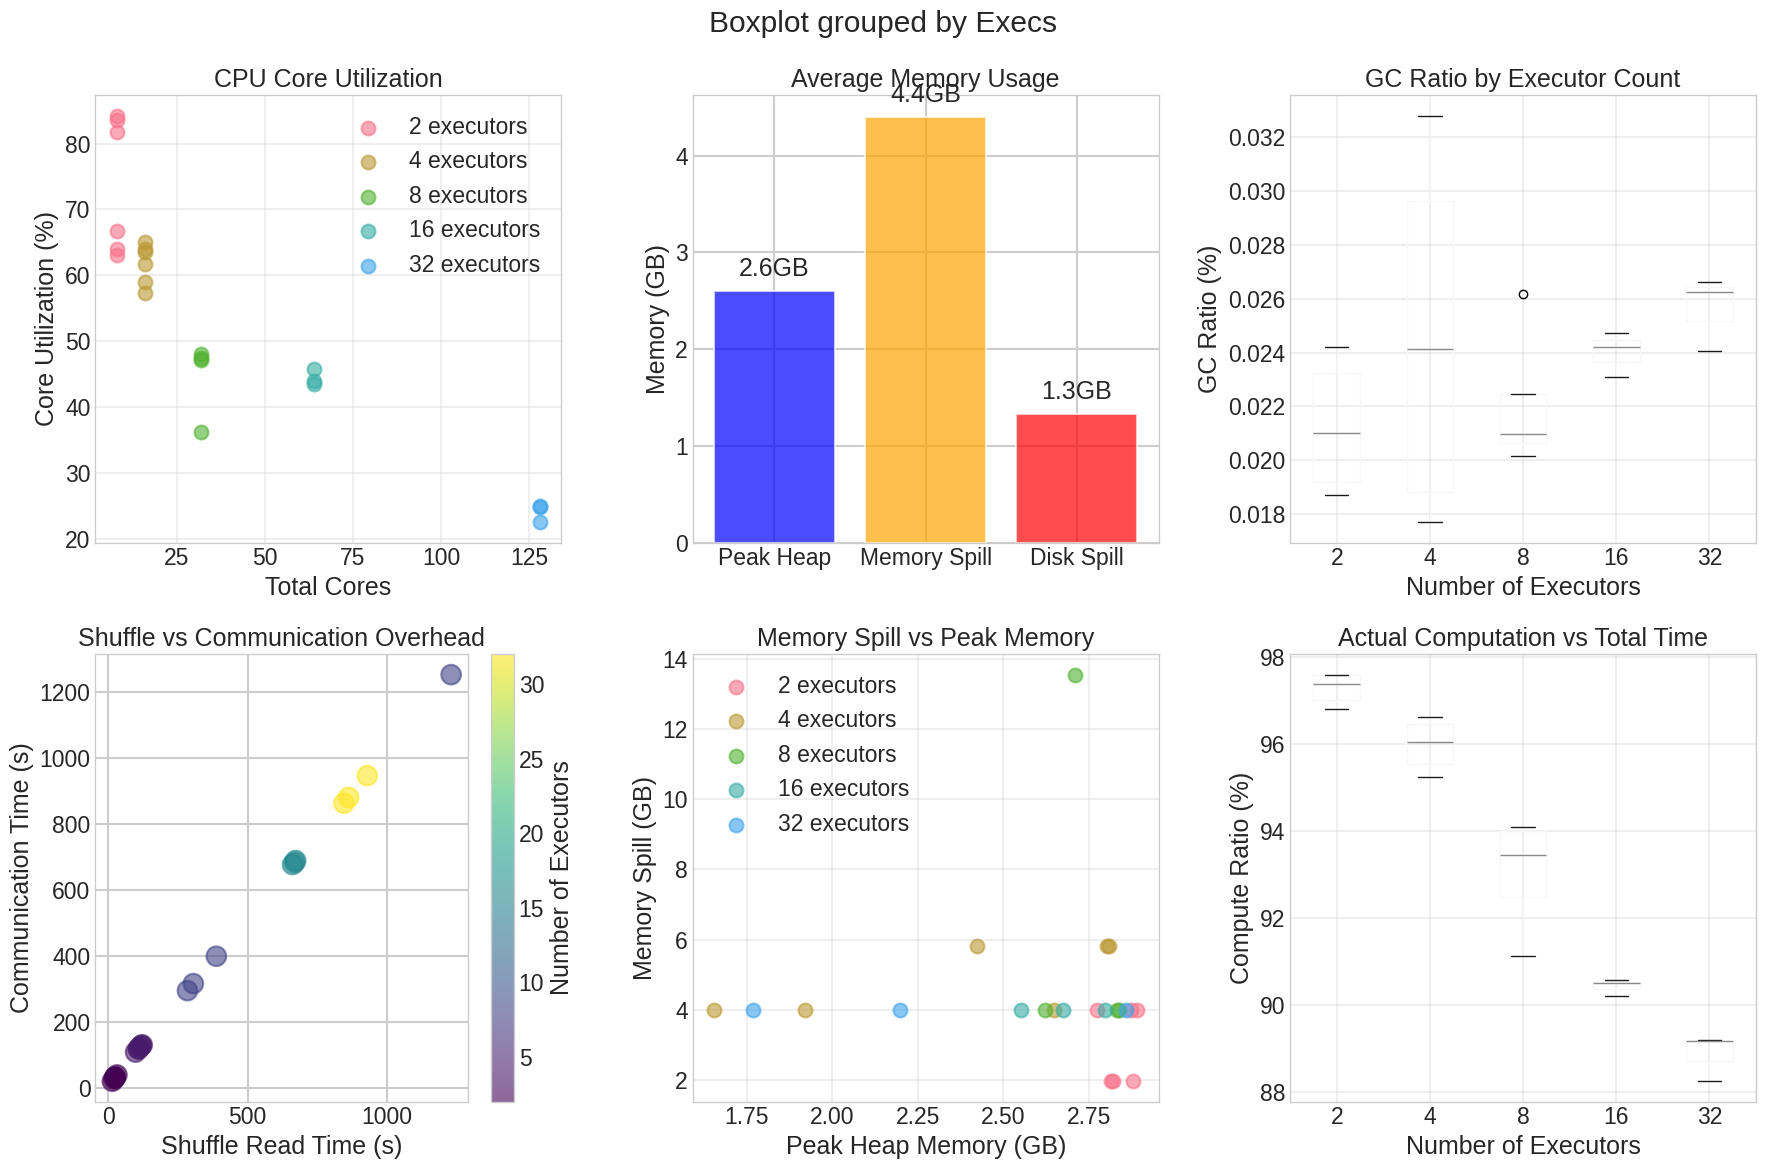

In [74]:
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle('Resource Utilization Analysis', fontsize=16, y=1.02)

# 1. CPU Utilization (Parallelism / TotalCores)
ax1 = axes[0, 0]
df['CoreUtilization'] = df['Parallelism'] / (df['Execs'] * df['Cores']) * 100

for execs in df['Execs'].unique():
    subset = df[df['Execs'] == execs]
    cores_total = subset['Execs'].iloc[0] * subset['Cores'].iloc[0]
    ax1.scatter([cores_total] * len(subset), subset['CoreUtilization'], 
                s=100, alpha=0.6, label=f'{execs} executors')

ax1.set_xlabel('Total Cores')
ax1.set_ylabel('Core Utilization (%)')
ax1.set_title('CPU Core Utilization')
ax1.legend()
ax1.grid(True, alpha=0.3)

# 2. Memory Usage
ax2 = axes[0, 1]
mem_columns = ['PeakHeapMB', 'MemSpillMB', 'DiskSpillMB']
mem_avg = df[mem_columns].mean()

bars = ax2.bar(['Peak Heap', 'Memory Spill', 'Disk Spill'], 
               mem_avg.values/1024, color=['blue', 'orange', 'red'], alpha=0.7)
ax2.set_ylabel('Memory (GB)')
ax2.set_title('Average Memory Usage')

# Add value labels
for bar in bars:
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height + 0.1,
             f'{height:.1f}GB', ha='center', va='bottom')

# 3. GC Ratio Distribution
ax3 = axes[0, 2]
df.boxplot(column='GCRatio', by='Execs', ax=ax3)
ax3.set_xlabel('Number of Executors')
ax3.set_ylabel('GC Ratio (%)')
ax3.set_title('GC Ratio by Executor Count')
ax3.grid(True, alpha=0.3)

# 4. Shuffle vs Communication
ax4 = axes[1, 0]
scatter = ax4.scatter(df['ShuffleReadMs']/1000, df['CommMs']/1000, 
                      c=df['Execs'], s=df['Cores']*50, alpha=0.6, cmap='viridis')
ax4.set_xlabel('Shuffle Read Time (s)')
ax4.set_ylabel('Communication Time (s)')
ax4.set_title('Shuffle vs Communication Overhead')
plt.colorbar(scatter, ax=ax4, label='Number of Executors')

# 5. Memory Spill vs Peak Memory
ax5 = axes[1, 1]
for execs in df['Execs'].unique():
    subset = df[df['Execs'] == execs]
    ax5.scatter(subset['PeakHeapMB']/1024, subset['MemSpillMB']/1024, 
                s=100, alpha=0.6, label=f'{execs} executors')

ax5.set_xlabel('Peak Heap Memory (GB)')
ax5.set_ylabel('Memory Spill (GB)')
ax5.set_title('Memory Spill vs Peak Memory')
ax5.legend()
ax5.grid(True, alpha=0.3)

# 6. Compute vs Total Time Ratio
ax6 = axes[1, 2]
df['ComputeRatio'] = df['ComputeMs'] / df['ExecRunTimeMs'] * 100
df.boxplot(column='ComputeRatio', by='Execs', ax=ax6)
ax6.set_xlabel('Number of Executors')
ax6.set_ylabel('Compute Ratio (%)')
ax6.set_title('Actual Computation vs Total Time')
ax6.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('resource_utilization.png', dpi=300, bbox_inches='tight')
plt.show()


## 5. **Summary Statistics Table**

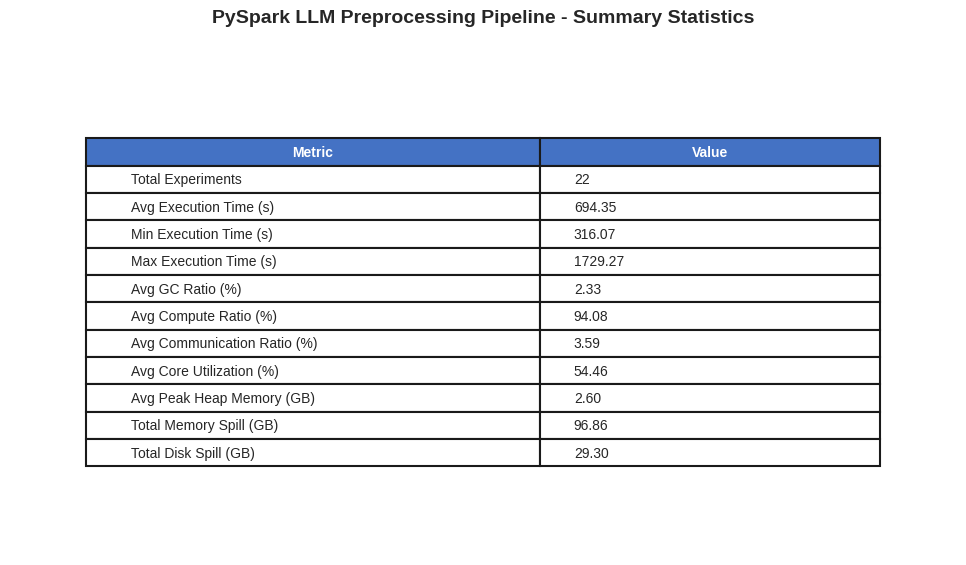


SUMMARY STATISTICS
                     Metric   Value
          Total Experiments      22
     Avg Execution Time (s)  694.35
     Min Execution Time (s)  316.07
     Max Execution Time (s) 1729.27
           Avg GC Ratio (%)    2.33
      Avg Compute Ratio (%)   94.08
Avg Communication Ratio (%)    3.59
   Avg Core Utilization (%)   54.46
  Avg Peak Heap Memory (GB)    2.60
    Total Memory Spill (GB)   96.86
      Total Disk Spill (GB)   29.30


In [75]:
# Create summary statistics table
summary = pd.DataFrame({
    'Metric': [
        'Total Experiments',
        'Avg Execution Time (s)',
        'Min Execution Time (s)',
        'Max Execution Time (s)',
        'Avg GC Ratio (%)',
        'Avg Compute Ratio (%)',
        'Avg Communication Ratio (%)',
        'Avg Core Utilization (%)',
        'Avg Peak Heap Memory (GB)',
        'Total Memory Spill (GB)',
        'Total Disk Spill (GB)'
    ],
    'Value': [
        len(df),
        f"{df['AppTimeMs'].mean()/1000:.2f}",
        f"{df['AppTimeMs'].min()/1000:.2f}",
        f"{df['AppTimeMs'].max()/1000:.2f}",
        f"{df['GCRatio'].mean()*100:.2f}",
        f"{df['ComputeRatio'].mean():.2f}",
        f"{df['CommRatio'].mean()*100:.2f}",
        f"{(df['Parallelism'] / (df['Execs'] * df['Cores'])).mean()*100:.2f}",
        f"{df['PeakHeapMB'].mean()/1024:.2f}",
        f"{df['MemSpillMB'].sum()/1024:.2f}",
        f"{df['DiskSpillMB'].sum()/1024:.2f}"
    ]
})

# Create figure for summary table
fig, ax = plt.subplots(figsize=(10, 6))
ax.axis('off')
ax.axis('tight')

table = ax.table(cellText=summary.values, colLabels=summary.columns,
                 cellLoc='left', loc='center', colWidths=[0.4, 0.3])
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1.2, 1.5)

# Style the header
for (i, j), cell in table.get_celld().items():
    if i == 0:
        cell.set_facecolor('#4472C4')
        cell.set_text_props(color='white', weight='bold')

plt.title('PySpark LLM Preprocessing Pipeline - Summary Statistics', 
          fontsize=14, weight='bold', pad=20)
plt.tight_layout()
plt.savefig('summary_statistics.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n" + "="*60)
print("SUMMARY STATISTICS")
print("="*60)
print(summary.to_string(index=False))

## 6. **Performance Recommendations Based on Data**

In [76]:
# Find best configuration
best_config = df.loc[df['AppTimeMs'].idxmin()]
print("\n" + "="*60)
print("BEST PERFORMANCE CONFIGURATION")
print("="*60)
print(f"Configuration: {best_config['Execs']} executors × {best_config['Cores']} cores = {best_config['TotalCores']} total cores")
print(f"Execution Time: {best_config['AppTimeMs']/1000:.2f} seconds")
print(f"Data Size: {best_config['Data']}")
print(f"Run Number: {best_config['Run']}")

# Find most efficient configuration (best time per core)
df['TimePerCore'] = df['AppTimeMs'] / df['TotalCores']
most_efficient = df.loc[df['TimePerCore'].idxmin()]
print("\n" + "="*60)
print("MOST EFFICIENT CONFIGURATION (Best Time per Core)")
print("="*60)
print(f"Configuration: {most_efficient['Execs']} executors × {most_efficient['Cores']} cores = {most_efficient['TotalCores']} total cores")
print(f"Execution Time: {most_efficient['AppTimeMs']/1000:.2f} seconds")
print(f"Time per Core: {most_efficient['TimePerCore']:.2f} ms/core")

# Calculate scalability metrics
strong_scaling = strong_df.groupby('TotalCores')['AppTimeMs'].mean().sort_index()
base_time = strong_scaling.iloc[0]
speedups = base_time / strong_scaling
print("\n" + "="*60)
print("STRONG SCALING METRICS")
print("="*60)
for cores, speedup in zip(strong_scaling.index, speedups):
    efficiency = (speedup / (cores / strong_scaling.index[0])) * 100
    print(f"{cores} cores: Speedup = {speedup:.2f}x, Efficiency = {efficiency:.1f}%")


BEST PERFORMANCE CONFIGURATION
Configuration: 16 executors × 4 cores = 64 total cores
Execution Time: 316.07 seconds
Data Size: small_2
Run Number: 3

MOST EFFICIENT CONFIGURATION (Best Time per Core)
Configuration: 32 executors × 4 cores = 128 total cores
Execution Time: 328.93 seconds
Time per Core: 2569.79 ms/core

STRONG SCALING METRICS
8 cores: Speedup = 1.00x, Efficiency = 100.0%
16 cores: Speedup = 1.29x, Efficiency = 64.3%
32 cores: Speedup = 1.95x, Efficiency = 48.6%
64 cores: Speedup = 3.00x, Efficiency = 37.5%
128 cores: Speedup = 2.96x, Efficiency = 18.5%
